# 교통사고유형별 발생분석
- https://www.data.go.kr/
- 표준데이터셋
- 전국교통사고다발지역표준데이터

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

file_path = './dataset/전국교통사고다발지역표준데이터.csv'
df = pd.read_csv(file_path, encoding="EUC-KR")
df.head() #['사고유형구분'].unique()

,사고지역관리번호,사고연도,사고유형구분,위치코드,사고다발지역시도시군구,사고지역위치명,사고건수,사상자수,사망자수,중상자수,경상자수,부상신고자수,위도,경도,사고다발지역폴리곤정보,데이터기준일자,제공기관코드,제공기관명
0,2025108,2024,보행어린이,52180001,전북특별자치도 정읍시1,전북특별자치도 정읍시 상동(한솔초등학교 부근),3,3,0,0,3,0,35.560543,126.873488,"{ type: Polygon, coordinates: [ [ [943222, 172...",2025-09-24,B555234,한국도로교통공단
1,2025108,2024,보행어린이,50110004,제주특별자치도 제주시4,제주특별자치도 제주시 일도이동(꼬마스쿨 어린이집 부근),3,3,0,0,2,1,33.504623,126.545344,"{ type: Polygon, coordinates: [ [ [911329.5, 1...",2025-09-24,B555234,한국도로교통공단
2,2025108,2024,보행어린이,50110003,제주특별자치도 제주시3,제주특별자치도 제주시 도남동(도남초등학교 부근),3,3,0,0,3,0,33.493613,126.528354,"{ type: Polygon, coordinates: [ [ [909740, 150...",2025-09-24,B555234,한국도로교통공단
3,2025108,2024,보행어린이,50110002,제주특별자치도 제주시2,제주특별자치도 제주시 연동(신제주초등학교입구교차로 부근),3,3,0,1,1,1,33.483884,126.496329,"{ type: Polygon, coordinates: [ [ [906754.5, 1...",2025-09-24,B555234,한국도로교통공단
4,2025108,2024,보행어린이,50110001,제주특별자치도 제주시1,제주특별자치도 제주시 노형동(세빛어린이집 부근),4,5,0,2,2,1,33.485919,126.473950,"{ type: Polygon, coordinates: [ [ [904677.5, 1...",2025-09-24,B555234,한국도로교통공단


Text(0.2, 0.4, '한글')

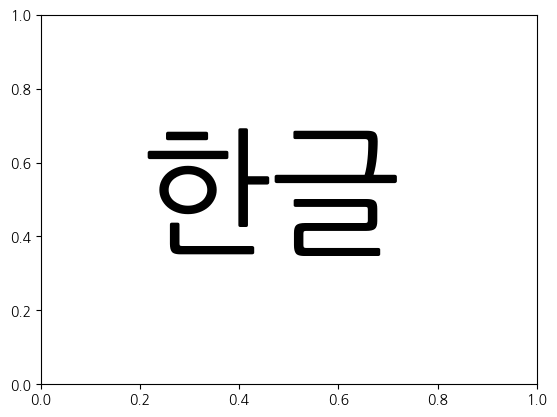

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rc('font', family='NanumGothic')
plt.text(0.2,0.4, '한글', size=100)

In [3]:
raw_data = df.copy()
raw_data = raw_data.groupby('사고유형구분')['사고건수'].sum().reset_index(name="count")
raw_data = raw_data.sort_values('count',ascending=False)
raw_data.columns = ['type','count']
raw_data.head()

,type,count
0,보행노인,26098
3,자전거,26040
1,보행어린이,4111
2,스쿨존어린이,1095


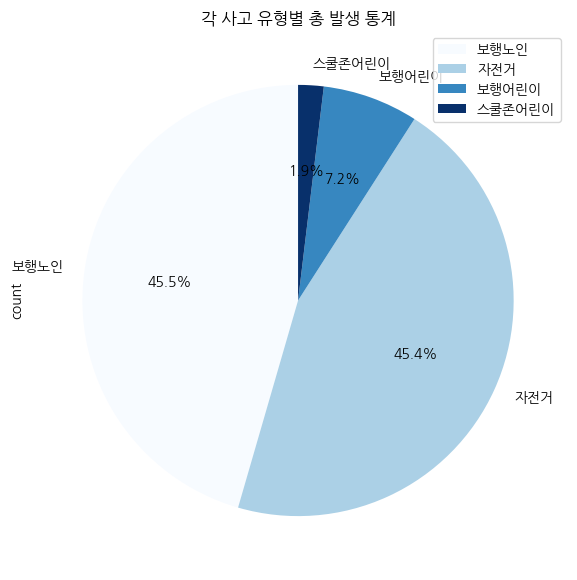

In [4]:
raw_data.plot(
    kind='pie',
    y='count',
    labels= raw_data['type'],
    figsize=(7,7),
    startangle=90,
    autopct='%2.1f%%',
    title='각 사고 유형별 총 발생 통계',
    cmap = matplotlib.cm.Blues
)
plt.show()

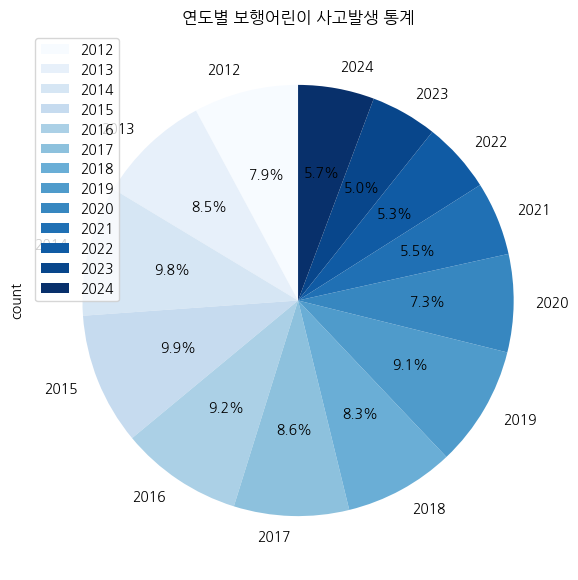

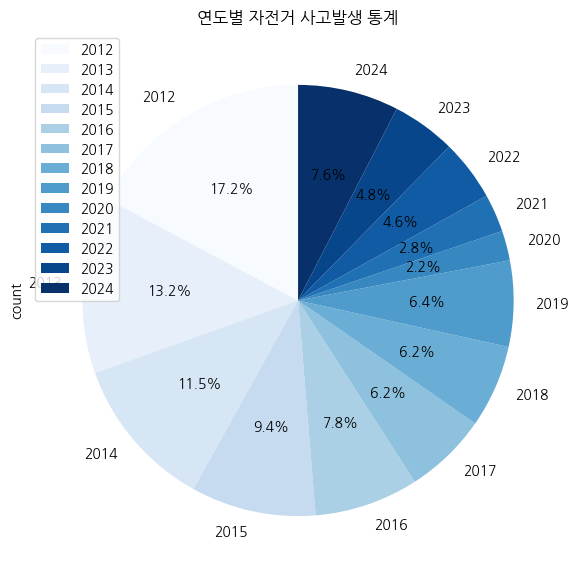

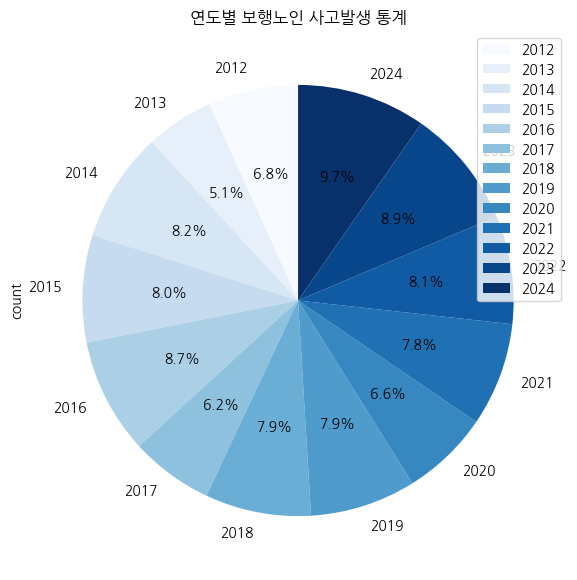

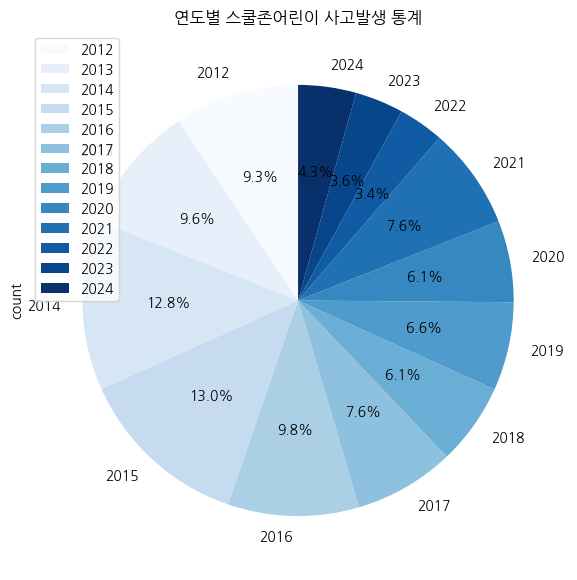

In [9]:
ex_data = df.copy()
ex_data = ex_data.rename(columns={'사고연도':'year','사고유형구분':'type','사고건수':'accident'})

#방법1a
arr_data = list(ex_data['type'].unique())

#방법1b
# arr_data = list(set(ex_data['type']))

#방법2a
data_list = [g for _ , g in ex_data.groupby('type')]

#방법2b
# data_list = []
# for a in arr_data:
# data_list.append(  ex_data[  ex_data['type']==a ] )
total =[]
for d in data_list:
    result = d.groupby('year')['accident'].sum().reset_index(name='count')
    total.append(result)

for x in range(len(arr_data)):
    total[x].plot(
        kind='pie',
        y='count',
        labels= total[x]['year'],
        figsize=(12,7),
        startangle=90,
        autopct='%2.1f%%',
        title=f'연도별 {arr_data[x]} 사고발생 통계',
        cmap = matplotlib.cm.Blues)
    plt.savefig(f"./chart/chart{x}.png")
# plt.show()

In [12]:
from IPython.display import display, HTML

html_raw = f"""
<div style="display: flex ;flex-wrap:wrap;width:1000px;">
    <div style="flex: 1; min-width:300px";>
        <div style="padding: 10px 0 10px 80px;">
        <h3>Data Table</h3>
        {raw_data.to_html(index=False)}
        </div>
    </div>"""
for v in range(len(arr_data)):
    html_raw += f"""<div style="flex: 1; padding: 10px; min-width:300px">
            <h3>Pie Chart{v+1}</h3>
            <img src="./chart/chart{v}.png" alt="Pie Chart">
        </div>"""
html_raw +=f"""</div> """

display(HTML(html_raw))

type,count
보행노인,26098
자전거,26040
보행어린이,4111
스쿨존어린이,1095
